# Data Wrangling / Data Munging / Data handling Continued

The steps related to this script:
In this part we will  handle the following steps :
1. Loading libraries - **Please note that, installation of libraries are mandatory prior to their import. Installation of the libraries has not been shown.(Please refer to the documentations for installing libraries in one's system.)**
2. consolidated_data_load_filled.csv is loaded
3. further Analysis of the file is done -

In [60]:
##!pip install seaborn

In [61]:
##!pip install scipy

## 1. Loading libraries
The following libraries are loaded:

* [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data, for time-series analysis and holiday calendar support
* [`NumPy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations
* [`Matplotlib`](https://matplotlib.org/) for creating static, animated, and interactive visualizations in Python
* [`seaborn`](https://seaborn.pydata.org/l) for high-level interface drawing attractive and informative statistical graphics
* [`warnings`](https://docs.python.org/3/library/warnings.html) for handling and suppressing warning messages


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     #for visualization
%matplotlib inline
import seaborn as sns               #for visualization
import warnings
warnings.filterwarnings('ignore')
     
print("libraries loaded sucessfully")

libraries loaded sucessfully


# 1. Intial inspection

In [63]:
df= pd.read_csv(r'D:\Documents\Maloshree\DATA ANALYTICS CERTIFICATION-INCO\Capstone Project\Data\consolidated_data_load_filled.csv')
df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,lag_2,price_avg,stock_avg,stockout_flag,inventory_turnover_ratio,promo_intensity,is_npi_flag,is_holiday,revenue,sales_total_monthly
0,2022-07-11,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.79,1,...,0,5.273722,413.55,1,0.805223,0.483722,1,0,253.87,333.0
1,2022-07-12,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,6.28,0,...,0,5.273722,413.55,0,0.805223,-1.006278,1,0,43.96,333.0
2,2022-07-16,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.40,0,...,0,5.273722,413.55,0,0.805223,0.873722,1,0,162.80,333.0
3,2022-07-21,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,1.96,0,...,0,5.219629,413.55,0,0.805223,3.259629,1,0,41.16,333.0
4,2022-07-26,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.57,0,...,0,5.249557,413.55,0,0.805223,0.679557,1,0,68.55,333.0


In [64]:
df.tail()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,lag_2,price_avg,stock_avg,stockout_flag,inventory_turnover_ratio,promo_intensity,is_npi_flag,is_holiday,revenue,sales_total_monthly
191176,2024-12-19,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,Retail,PL-South,Single,8.71,0,...,0,5.265412,559.3,0,0.740211,-3.444588,1,0,113.23,414.0
191177,2024-12-21,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,Retail,PL-South,Single,3.57,0,...,0,5.265412,559.3,0,0.740211,1.695412,1,0,74.97,414.0
191178,2024-12-22,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,Retail,PL-South,Single,2.43,1,...,0,5.249205,559.3,0,0.740211,2.819205,1,0,63.18,414.0
191179,2024-12-23,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,Retail,PL-South,Single,8.18,0,...,0,5.249205,559.3,0,0.740211,-2.930795,1,0,130.88,414.0
191180,2024-12-30,YO-029,YoBrand4,Yogurt-Seg2,Yogurt,Retail,PL-South,Single,5.08,0,...,0,5.196873,559.3,0,0.740211,0.116873,1,0,50.80,414.0


In [65]:
df.shape

(191181, 33)

In [66]:
df.columns

Index(['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region',
       'pack_type', 'price_unit', 'promotion_flag', 'delivery_days',
       'stock_available', 'delivered_qty', 'units_sold', 'is_holiday_peak',
       'week_number', 'month_m', 'year_y', 'is_holiday_week', 'is_summer',
       'is_winter', 'lifecycle_stage', 'lag_1', 'lag_2', 'price_avg',
       'stock_avg', 'stockout_flag', 'inventory_turnover_ratio',
       'promo_intensity', 'is_npi_flag', 'is_holiday', 'revenue',
       'sales_total_monthly'],
      dtype='str')

# 2.Understanding Data Types, Structure and Descriptive Statistics

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 191181 entries, 0 to 191180
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      191181 non-null  str    
 1   sku                       191181 non-null  str    
 2   brand                     191181 non-null  str    
 3   segment                   191181 non-null  str    
 4   category                  191181 non-null  str    
 5   channel                   191181 non-null  str    
 6   region                    191181 non-null  str    
 7   pack_type                 191181 non-null  str    
 8   price_unit                191181 non-null  float64
 9   promotion_flag            191181 non-null  int64  
 10  delivery_days             191181 non-null  float64
 11  stock_available           191181 non-null  int64  
 12  delivered_qty             191181 non-null  float64
 13  units_sold                191181 non-null  float64
 14 

In [68]:
df.isnull().sum()

date                        0
sku                         0
brand                       0
segment                     0
category                    0
channel                     0
region                      0
pack_type                   0
price_unit                  0
promotion_flag              0
delivery_days               0
stock_available             0
delivered_qty               0
units_sold                  0
is_holiday_peak             0
week_number                 0
month_m                     0
year_y                      0
is_holiday_week             0
is_summer                   0
is_winter                   0
lifecycle_stage             0
lag_1                       0
lag_2                       0
price_avg                   0
stock_avg                   0
stockout_flag               0
inventory_turnover_ratio    0
promo_intensity             0
is_npi_flag                 0
is_holiday                  0
revenue                     0
sales_total_monthly         0
dtype: int

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.describe()

,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,is_holiday_peak,week_number,month_m,year_y,...,lag_2,price_avg,stock_avg,stockout_flag,inventory_turnover_ratio,promo_intensity,is_npi_flag,is_holiday,revenue,sales_total_monthly
count,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,...,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000,191181.000000
mean,5.251969,0.151160,3.004391,662.040600,179.220299,20.227857,0.032331,28.663983,6.946381,2023.288695,...,0.386895,5.251401,662.040600,0.117214,0.823692,-0.000567,0.954781,0.030160,106.208944,538.703412
std,2.161777,0.358206,1.411894,489.949465,40.151812,12.838962,0.176877,14.814605,3.379253,0.717232,...,6.485425,0.033995,130.231649,0.321675,0.265725,2.161629,0.207785,0.171028,84.063568,184.519379
min,1.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2022.000000,...,0.000000,5.195433,0.000000,0.000000,0.000000,-3.804567,0.000000,0.000000,0.000000,6.000000
25%,3.380000,0.000000,2.000000,261.000000,152.000000,12.000000,0.000000,17.000000,4.000000,2023.000000,...,0.000000,5.226411,576.000000,0.000000,0.634956,-1.866825,1.000000,0.000000,50.700000,414.000000
50%,5.250000,0.000000,3.000000,604.000000,179.000000,18.000000,0.000000,29.000000,7.000000,2023.000000,...,0.000000,5.249205,660.500000,0.000000,0.771669,-0.001018,1.000000,0.000000,85.860000,509.000000
75%,7.120000,0.000000,4.000000,998.000000,206.000000,25.000000,0.000000,42.000000,10.000000,2024.000000,...,0.000000,5.278982,746.843750,0.000000,0.961380,1.865412,1.000000,0.000000,137.180000,633.000000
max,9.000000,1.000000,5.000000,2987.000000,366.000000,248.000000,1.000000,53.000000,12.000000,2025.000000,...,248.000000,5.340964,1114.277778,1.000000,3.564078,3.840964,1.000000,1.000000,1661.350000,2138.000000


In [71]:
# This summarizes the object/string columns
df.describe(include=['O'])

,date,sku,brand,segment,category,channel,region,pack_type,lifecycle_stage
count,191181,191181,191181,191181,191181,191181,191181,191181,191181
unique,1102,30,14,13,5,3,3,3,4
top,2024-07-30,MI-006,SnBrand2,Yogurt-Seg1,Yogurt,Retail,PL-North,Single,Introduction
freq,248,8645,26775,26851,72707,63824,63792,64209,182536


In [72]:
# This summarizes only the numerical columns
print(df.describe(include=[np.number]))

          price_unit  promotion_flag  delivery_days  stock_available  \
count  191181.000000   191181.000000  191181.000000    191181.000000   
mean        5.251969        0.151160       3.004391       662.040600   
std         2.161777        0.358206       1.411894       489.949465   
min         1.500000        0.000000       1.000000         0.000000   
25%         3.380000        0.000000       2.000000       261.000000   
50%         5.250000        0.000000       3.000000       604.000000   
75%         7.120000        0.000000       4.000000       998.000000   
max         9.000000        1.000000       5.000000      2987.000000   

       delivered_qty     units_sold  is_holiday_peak    week_number  \
count  191181.000000  191181.000000    191181.000000  191181.000000   
mean      179.220299      20.227857         0.032331      28.663983   
std        40.151812      12.838962         0.176877      14.814605   
min         0.000000       0.000000         0.000000       1.000000

# 3.  Data Distribution Analysis

In [73]:
df.skew(numeric_only=True)

price_unit                  -0.001276
promotion_flag               1.947724
delivery_days               -0.007353
stock_available              0.571112
delivered_qty               -0.016565
units_sold                   2.696738
is_holiday_peak              5.288126
week_number                 -0.141174
month_m                     -0.150918
year_y                      -0.470392
is_holiday_week              1.425389
is_summer                    1.064567
is_winter                    1.304126
lag_1                       18.819914
lag_2                       18.832323
price_avg                    0.421964
stock_avg                   -0.042343
stockout_flag                2.379980
inventory_turnover_ratio     1.671661
promo_intensity              0.001238
is_npi_flag                 -4.377476
is_holiday                   5.494377
revenue                      2.485970
sales_total_monthly          1.455892
dtype: float64

In [74]:
df.kurt(numeric_only=True)

price_unit                   -1.194448
promotion_flag                1.793646
delivery_days                -1.295741
stock_available              -0.264618
delivered_qty                 0.005223
units_sold                   16.611068
is_holiday_peak              25.964553
week_number                  -1.127502
month_m                      -1.135093
year_y                       -0.926598
is_holiday_week               0.031733
is_summer                    -0.866707
is_winter                    -0.299258
lag_1                       395.716811
lag_2                       397.171005
price_avg                    -0.218139
stock_avg                     0.473292
stockout_flag                 3.664342
inventory_turnover_ratio      6.914540
promo_intensity              -1.193846
is_npi_flag                  17.162473
is_holiday                   28.188474
revenue                      12.196639
sales_total_monthly           5.495599
dtype: float64

In [75]:
num_cols = [
    "price_unit", "delivery_days", "stock_available", "delivered_qty","price_avg", "stock_avg",
    "units_sold", "revenue", "sales_total_monthly", "inventory_turnover_ratio","lag_1", "lag_2", "promo_intensity"]

cat_cols =["sku", "brand", "segment", "category", "channel", "region",
       "pack_type", "life_cycle_stage","date", "promotion_flag","is_holiday_peak", "week_number", "month_m", "year_y", "is_holiday_week", "is_summer",
       "is_winter", "lifecycle_stage", "stockout_flag", "is_npi_flag", "is_holiday"]


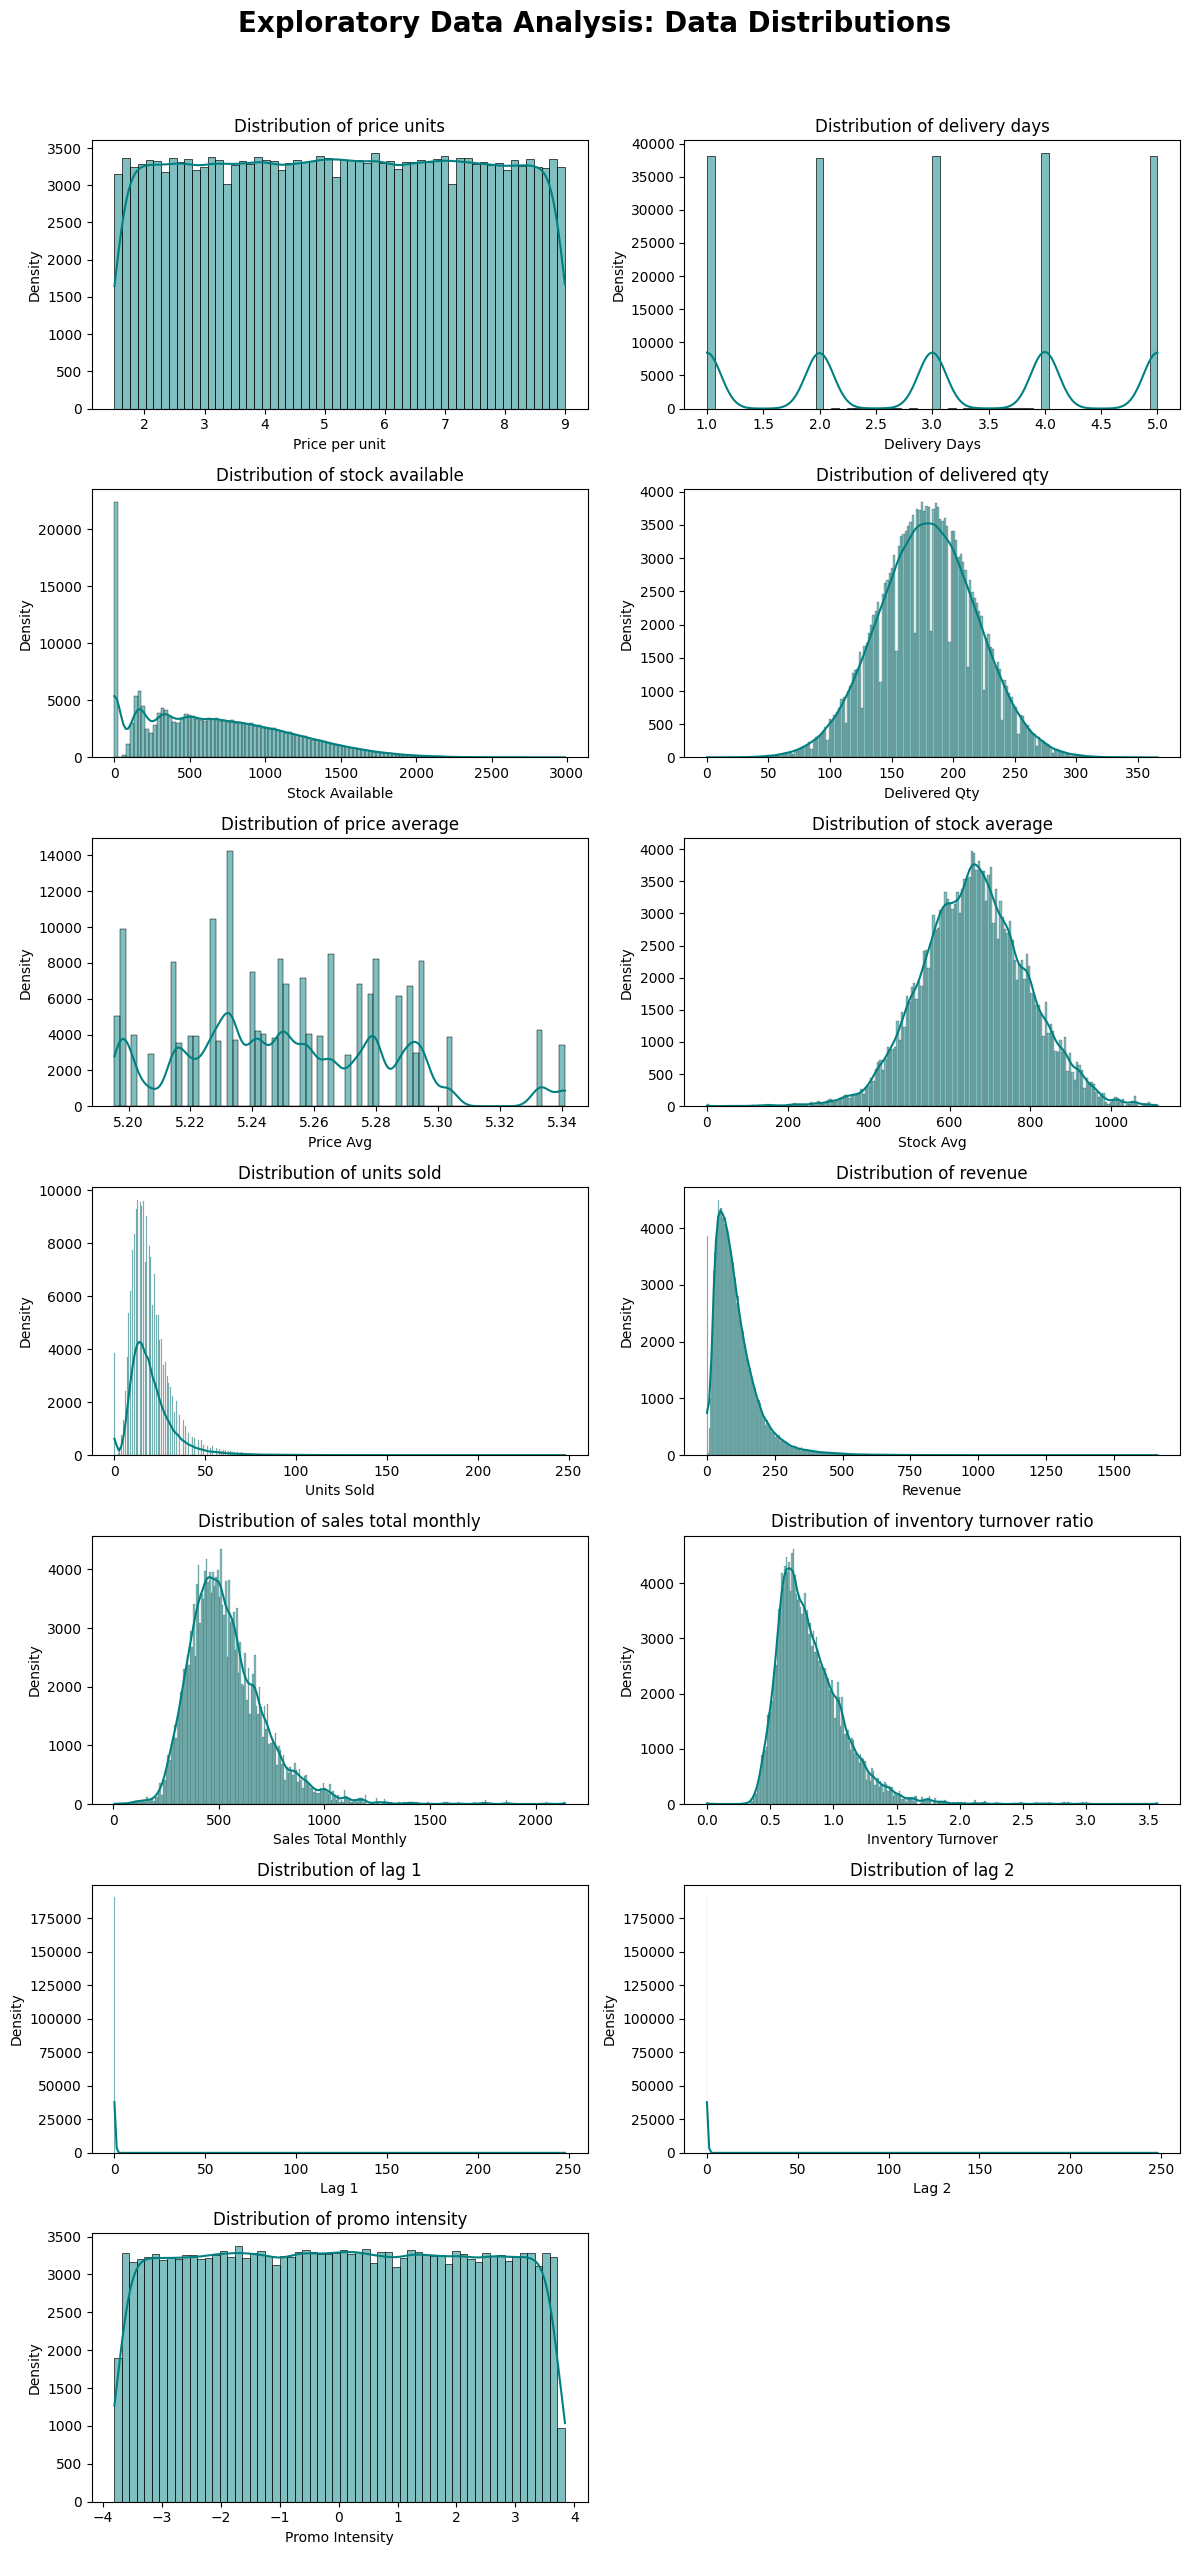

In [76]:
# Distribution of data density using histograms
#  Update the grid size to 7 rows, 2 columns to accommodate 13+ plots
fig, axs = plt.subplots(7, 2, figsize=(12, 25))
axs = axs.flatten() 
fig.suptitle('Exploratory Data Analysis: Data Distributions', fontsize=20, fontweight='bold', y=1.02)
# 1. price_unit
sns.histplot(df["price_unit"], kde=True, ax=axs[0], color='teal')
axs[0].set_title('Distribution of price units', fontsize=12) # Fixed: fontsize
axs[0].set_xlabel("Price per unit")
axs[0].set_ylabel("Density")

# 2. delivery_days
sns.histplot(df["delivery_days"], kde=True, ax=axs[1], color='teal')
axs[1].set_title('Distribution of delivery days', fontsize=12)
axs[1].set_xlabel("Delivery Days")
axs[1].set_ylabel("Density")

# 3. stock_available
sns.histplot(df["stock_available"], kde=True, ax=axs[2], color='teal')
axs[2].set_title('Distribution of stock available', fontsize=12)
axs[2].set_xlabel("Stock Available")
axs[2].set_ylabel("Density")

# 4. delivered_qty
sns.histplot(df["delivered_qty"], kde=True, ax=axs[3], color='teal')
axs[3].set_title('Distribution of delivered qty', fontsize=12)
axs[3].set_xlabel("Delivered Qty")
axs[3].set_ylabel("Density")

# 5. price_avg
sns.histplot(df["price_avg"], kde=True, ax=axs[4], color='teal')
axs[4].set_title('Distribution of price average', fontsize=12)
axs[4].set_xlabel("Price Avg")
axs[4].set_ylabel("Density")

# 6. stock_avg
sns.histplot(df["stock_avg"], kde=True, ax=axs[5], color='teal')
axs[5].set_title('Distribution of stock average', fontsize=12)
axs[5].set_xlabel("Stock Avg")
axs[5].set_ylabel("Density")

# 7. units_sold
sns.histplot(df["units_sold"], kde=True, ax=axs[6], color='teal')
axs[6].set_title('Distribution of units sold', fontsize=12)
axs[6].set_xlabel("Units Sold")
axs[6].set_ylabel("Density")

# 8. revenue
sns.histplot(df["revenue"], kde=True, ax=axs[7], color='teal')
axs[7].set_title('Distribution of revenue', fontsize=12)
axs[7].set_xlabel("Revenue")
axs[7].set_ylabel("Density")

# 9. sales_total_monthly
sns.histplot(df["sales_total_monthly"], kde=True, ax=axs[8], color='teal')
axs[8].set_title('Distribution of sales total monthly', fontsize=12)
axs[8].set_xlabel("Sales Total Monthly")
axs[8].set_ylabel("Density")

# 10. inventory_turnover_ratio
sns.histplot(df["inventory_turnover_ratio"], kde=True, ax=axs[9], color='teal')
axs[9].set_title('Distribution of inventory turnover ratio', fontsize=12)
axs[9].set_xlabel("Inventory Turnover")
axs[9].set_ylabel("Density")

# 11. lag_1
sns.histplot(df["lag_1"], kde=True, ax=axs[10], color='teal')
axs[10].set_title('Distribution of lag 1', fontsize=12)
axs[10].set_xlabel("Lag 1")
axs[10].set_ylabel("Density")

# 12. lag_2
sns.histplot(df["lag_2"], kde=True, ax=axs[11], color='teal')
axs[11].set_title('Distribution of lag 2', fontsize=12)
axs[11].set_xlabel("Lag 2")
axs[11].set_ylabel("Density")

# 13. promo_intensity
sns.histplot(df["promo_intensity"], kde=True, ax=axs[12], color='teal')
axs[12].set_title('Distribution of promo intensity', fontsize=12)
axs[12].set_xlabel("Promo Intensity")
axs[12].set_ylabel("Density")

# Hide the 14th empty subplot (since we have an odd number of plots)
axs[13].set_visible(False)

# Tight layout
plt.tight_layout()
plt.show()

In [77]:
# Calculation of mean median mode of each columns:
central_tendency = pd.DataFrame({
    "Mean":   df[num_cols].mean(),            # Average
    "Median": df[num_cols].median(),           # Middle value
    "Mode":   df[num_cols].mode().iloc[0],    # Most common value
})
 
print("\n Central Tendency Table:")
print(central_tendency.round(2))


 Central Tendency Table:
                            Mean  Median    Mode
price_unit                  5.25    5.25    1.65
delivery_days               3.00    3.00    4.00
stock_available           662.04  604.00    0.00
delivered_qty             179.22  179.00  175.00
price_avg                   5.25    5.25    5.25
stock_avg                 662.04  660.50  716.00
units_sold                 20.23   18.00   13.00
revenue                   106.21   85.86    0.00
sales_total_monthly       538.70  509.00  513.00
inventory_turnover_ratio    0.82    0.77    0.97
lag_1                       0.39    0.00    0.00
lag_2                       0.39    0.00    0.00
promo_intensity            -0.00   -0.00    3.13
